# Day 107 — Logistic Regression + Classification Foundations
**Month 6 | Week 3 | ML Foundations | 80 Points + 10★ Bonus**

---

### Business Scenario
You are a **Data Analyst at ShopEase**.  
The Head of Growth asks: **"Can we predict which customers are likely to churn — stop purchasing — in the next 30 days?"**

If you can flag high-risk churners early, ShopEase can:
- Send targeted retention offers before the customer leaves
- Avoid wasting discounts on loyal customers who would have returned anyway
- Quantify churn risk in a portfolio dashboard for leadership

**Your job today:** Build a logistic regression model that classifies customers as `churn = 1` or `churn = 0`, evaluate it properly (accuracy is NOT enough), and explain the result in business language.

---

### Why logistic regression — not linear regression?
`order_value` is a continuous number → **linear regression**.  
`churn` is a binary label (Yes/No) → **logistic regression**.  
Logistic regression predicts the *probability* of belonging to a class, then thresholds it.

---

### Sections
| Section | Topic | Points |
|---------|-------|--------|
| **A** | Data Setup + Class Balance Check | 15 pts |
| **B** | Logistic Regression — Fit + Predict | 20 pts |
| **C** | Evaluation Metrics (beyond accuracy) | 25 pts |
| **D** | Threshold Tuning + ROC Curve | 10 pts |
| **E** | Business Interpretation (NRA) | 10 pts |
| **★ Bonus** | Precision-Recall tradeoff explanation | 10 pts |

**Total: 80 pts + 10★**

---

> ⚠️ **Rules:**
> 1. Run cells top-to-bottom before submitting.
> 2. `savefig()` **before** `plt.show()` — always.
> 3. Every written insight → NRA format (Number + Reason + Action).
> 4. Never modify the raw data cell.


---
## Section 1 — Raw Data
⚠️ **Do NOT modify this cell or the cell below.**

In [1]:
# ── RAW DATA (DO NOT MODIFY) ─────────────────────────────────────────────────
import pandas as pd
import numpy as np

np.random.seed(42)
n = 300

categories  = ['Electronics', 'Clothing', 'Home & Kitchen', 'Books', 'Sports']
segments    = ['Budget', 'Mid-tier', 'Premium']

df_raw = pd.DataFrame({
    'customer_id'      : [f'C{str(i).zfill(4)}' for i in range(1, n+1)],
    'age'              : np.random.randint(22, 60, n),
    'days_since_last'  : np.random.randint(1, 120, n),   # days since last purchase
    'total_orders'     : np.random.randint(1, 40,  n),
    'avg_order_value'  : np.round(np.random.uniform(300, 4500, n), 2),
    'discount_pct'     : np.round(np.random.uniform(0, 30, n), 1),
    'category'         : np.random.choice(categories, n),
    'segment'          : np.random.choice(segments, n, p=[0.45, 0.35, 0.20]),
    'support_tickets'  : np.random.randint(0, 6, n),
    'returns_count'    : np.random.randint(0, 5, n),
})

# ── Churn label: deterministic rule (not random) so model can learn it ────────
# Higher days_since_last + low orders + high returns → more likely to churn
churn_score = (
      0.04 * df_raw['days_since_last']
    - 0.05 * df_raw['total_orders']
    + 0.15 * df_raw['returns_count']
    + 0.10 * df_raw['support_tickets']
    - 0.002 * df_raw['avg_order_value']
)
churn_prob = 1 / (1 + np.exp(-churn_score))          # sigmoid
df_raw['churn'] = (churn_prob > 0.50).astype(int)    # 1 = churned, 0 = retained

print("Dataset shape:", df_raw.shape)
print("\nFirst 5 rows:")
display(df_raw.head())
print("\nChurn distribution:")
print(df_raw['churn'].value_counts())


Dataset shape: (300, 11)

First 5 rows:


,customer_id,age,days_since_last,total_orders,avg_order_value,discount_pct,category,segment,support_tickets,returns_count,churn
0,C0001,50,106,14,4066.41,28.1,Electronics,Budget,2,0,0
1,C0002,36,2,31,636.98,22.0,Books,Mid-tier,2,4,0
2,C0003,29,90,5,2502.95,6.4,Electronics,Mid-tier,3,3,0
3,C0004,42,17,35,2023.67,0.9,Home & Kitchen,Mid-tier,2,0,0
4,C0005,40,104,23,4425.99,7.9,Home & Kitchen,Mid-tier,2,4,0



Churn distribution:
churn
0    247
1     53
Name: count, dtype: int64


---
## Section 2 — Practice Guide

Work through **A → B → C → D → E** in order. Each section builds on the previous one.

---

### Section A — Data Setup + Class Balance Check (15 pts)

**A1 (5 pts):** Print dataset shape, dtypes, and missing value counts.  
Then print the **churn rate** as a percentage: `churn=1` count ÷ total × 100.  
*Why: A 5% churn rate needs a different approach than a 50% rate. Always report it.*

**A2 (5 pts):** Create a **count plot** of churn (0 vs 1) coloured by `segment`.  
Save as `A2_churn_by_segment.png`. Title: "Churn Distribution by Customer Segment".  
*Why: class imbalance is visible here — if one bar is 10× taller, you have a problem.*

**A3 (5 pts):** Compute and print the **mean of each numeric feature** split by churn label.  
Format: `df_raw.groupby('churn')[numeric_cols].mean().round(2)`  
Write 1 sentence: which feature shows the biggest difference between churned vs retained?

---

### Section B — Logistic Regression: Fit + Predict (20 pts)

**B1 (10 pts):** Feature engineering:
- One-hot encode `category` and `segment` (use `pd.get_dummies`, `drop_first=True`)
- Define `X` (all features except `customer_id` and `churn`) and `y = df_raw['churn']`
- Split 80/20, `random_state=42`, `stratify=y`
- Print: `X_train shape`, `X_test shape`, `train churn rate`, `test churn rate`

*Why stratify? To ensure both splits have the same churn ratio — critical for imbalanced data.*

**B2 (10 pts):** Fit `LogisticRegression(max_iter=1000, random_state=42)`.  
Print:
```
Train Accuracy : X.XX
Test  Accuracy : X.XX
```
Then print `classification_report(y_test, y_pred)`.  
Write 1 sentence: is the test accuracy meaningfully different from train? What does that tell you?

---

### Section C — Evaluation Metrics Beyond Accuracy (25 pts)

**C1 (10 pts):** Plot the **confusion matrix** using `ConfusionMatrixDisplay`.  
Save as `C1_confusion_matrix.png`.  
Below the plot, print and label manually:
```
True Positives  (TP) : correctly predicted churners
False Positives (FP) : predicted churn, actually retained
False Negatives (FN) : predicted retained, actually churned  ← most costly
True Negatives  (TN) : correctly predicted retained
```

**C2 (10 pts):** Compute and print:
```
Precision : TP / (TP + FP)   → "Of all I flagged as churners, how many really churned?"
Recall    : TP / (TP + FN)   → "Of all real churners, how many did I catch?"
F1 Score  : harmonic mean of precision and recall
```
*Use `sklearn.metrics` — don't compute manually. But write the formula in a comment.*

**C3 (5 pts):** In 2–3 sentences, explain: **for churn prediction, which matters more — precision or recall? Why?**  
*Hint: think about the cost of missing a churner vs. annoying a loyal customer.*

---

### Section D — Threshold Tuning + ROC Curve (10 pts)

**D1 (5 pts):** Plot the **ROC curve** and compute AUC.  
Save as `D1_roc_curve.png`.  
Add a dashed diagonal (random classifier baseline).  
Title: `f"ROC Curve — AUC = {auc_score:.3f}"`.

**D2 (5 pts):** Use `predict_proba` to get churn probabilities.  
Test thresholds: `[0.3, 0.4, 0.5, 0.6]`.  
Print a table:
```
Threshold | Precision | Recall | F1
```
Write 1 sentence: which threshold would you recommend and why?

---

### Section E — Business Interpretation / NRA (10 pts)

Write **3 NRA bullets** using actual numbers from your output:

**E1-a** (Churn rate + action):  
`[X]% of ShopEase customers are predicted to churn. [Reason]. ShopEase should [Action].`

**E1-b** (Most predictive feature + action):  
`Customers with [feature] of [value] churn at [X]× the base rate. [Reason]. [Action].`

**E1-c** (Threshold recommendation + action):  
`A threshold of [X] gives recall of [X]% at precision [X]%. [Reason]. [Action — who gets contacted].`

---

### ★ Bonus — Precision-Recall Tradeoff (10 pts)

**★1:** Plot the **Precision-Recall curve** (not ROC).  
Save as `BONUS_pr_curve.png`.  
Add a horizontal dashed line at the baseline precision (= churn rate).

**★2:** In 3–5 sentences, explain the **precision-recall tradeoff** in plain English using the ShopEase churn context:
- What happens when you lower the threshold?
- When would you prioritise precision over recall?
- In a real project, who (stakeholder) decides the threshold — analyst or business owner?


---
## Section 3 — Concept Notes

### 3.1 Logistic Regression — What it actually does

Logistic regression doesn't predict a number — it predicts a **probability between 0 and 1**.

```
P(churn=1) = sigmoid(β₀ + β₁x₁ + β₂x₂ + ...)

sigmoid(z) = 1 / (1 + e^(-z))     ← always returns a value in (0, 1)
```

The model learns the `β` coefficients. If `P(churn) > threshold (default 0.5)` → predict churn.

**Key property:** Logistic regression is a *linear classifier* — it draws a straight line (hyperplane in higher dimensions) to separate classes.

---

### 3.2 Why Accuracy Alone Is Misleading

Imagine 95% of customers are retained (churn = 0).  
A model that **always predicts 0** gets 95% accuracy — but is completely useless.

This is the **accuracy paradox**. You need:

| Metric | Formula | Business meaning |
|--------|---------|-----------------|
| **Precision** | TP/(TP+FP) | Of all flagged churners — how many really churned? |
| **Recall** | TP/(TP+FN) | Of all real churners — how many did we catch? |
| **F1** | 2×P×R/(P+R) | Balance of precision and recall |
| **AUC-ROC** | Area under ROC curve | Overall ranking ability (0.5 = random, 1.0 = perfect) |

---

### 3.3 The Confusion Matrix

```
                  Predicted 0    Predicted 1
Actual 0      [  TN          |   FP (Type I)  ]
Actual 1      [  FN (Type II)|   TP           ]
```

**FN (False Negative) = the worst error in churn prediction.**  
You miss a real churner → they leave → revenue lost.  
FP is less bad: you send an offer to someone who wasn't going to churn. Small cost.

---

### 3.4 Threshold Tuning

Default threshold = 0.5.  
Lowering to 0.3 → more positives predicted → recall ↑, precision ↓.  
Raising to 0.7 → fewer positives → precision ↑, recall ↓.

**In client work:** the business owner decides the acceptable threshold, not the analyst.  
The analyst presents the tradeoff table; the business sets the priority.

---

### 3.5 ROC vs Precision-Recall Curve

| | ROC Curve | Precision-Recall Curve |
|-|-----------|----------------------|
| **X-axis** | FPR (False Positive Rate) | Recall |
| **Y-axis** | TPR (Recall) | Precision |
| **Use when** | Classes relatively balanced | Imbalanced classes |
| **Baseline** | Diagonal (random) | Horizontal at churn rate |

For imbalanced churn data → **Precision-Recall curve is more informative**.

---

### 3.6 Interview: How to frame logistic regression

> "Logistic regression is my go-to first model for binary classification. It's fast, interpretable — I can show a client which features drive churn risk by looking at coefficients — and it gives calibrated probabilities. I always evaluate using precision, recall, and AUC rather than accuracy alone, especially with class imbalance. If a tree-based model beats it by <2% AUC, I'd still recommend logistic regression to the client because the explainability is worth more than marginal accuracy."


In [2]:
# A1  Shape, dtypes, missing, churn rate
# Goal: Print dataset shape, data types, missing counts, and overall churn rate.
# Method: Use df.shape, df.dtypes, df.isnull().sum(), and value_counts(normalize=True).

print("Dataset shape:", df_raw.shape)
print("\nData types:\n", df_raw.dtypes)
print("\nMissing values per column:\n", df_raw.isnull().sum())

churn_rate = df_raw['churn'].mean() * 100
print(f"\nOverall churn rate: {churn_rate:.2f}% ({df_raw['churn'].sum()} churned out of {len(df_raw)})")

Dataset shape: (300, 11)

Data types:
 customer_id         object
age                  int32
days_since_last      int32
total_orders         int32
avg_order_value    float64
discount_pct       float64
category            object
segment             object
support_tickets      int32
returns_count        int32
churn                int64
dtype: object

Missing values per column:
 customer_id        0
age                0
days_since_last    0
total_orders       0
avg_order_value    0
discount_pct       0
category           0
segment            0
support_tickets    0
returns_count      0
churn              0
dtype: int64

Overall churn rate: 17.67% (53 churned out of 300)


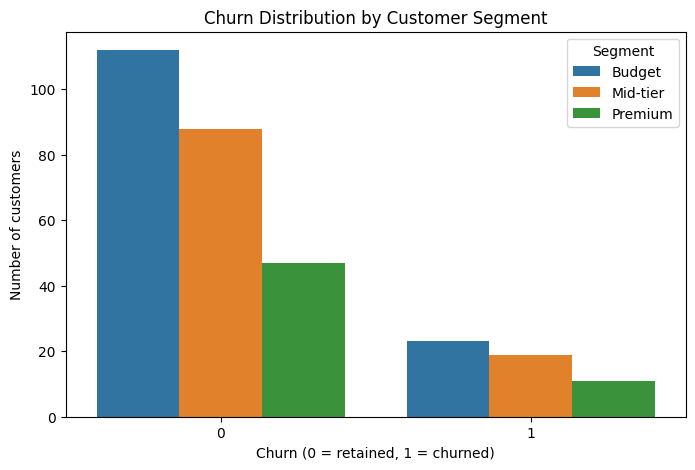

In [3]:
# A2 Count plot of churn by segment
# Goal: Visualise churn distribution across customer segments.
# Method: Use seaborn countplot with hue='segment', then save before showing.

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(data=df_raw, x='churn', hue='segment')
plt.title("Churn Distribution by Customer Segment")
plt.xlabel("Churn (0 = retained, 1 = churned)")
plt.ylabel("Number of customers")
plt.legend(title='Segment')
plt.savefig('A2_churn_by_segment.png', bbox_inches='tight')
plt.show()

In [4]:
# A3 Mean numeric features by churn label
# Goal: Identify which numeric feature differs most between churned and retained customers.
# Method: Group by 'churn' and compute means for all numeric columns.

numeric_cols = ['age', 'days_since_last', 'total_orders', 'avg_order_value', 
                'discount_pct', 'support_tickets', 'returns_count']
group_means = df_raw.groupby('churn')[numeric_cols].mean().round(2)
print(group_means)

# Find largest absolute difference
diff = group_means.loc[1] - group_means.loc[0]
print("\nFeature with biggest difference:", diff.abs().idxmax(), 
      f"(difference = {diff.abs().max():.2f})")

         age  days_since_last  total_orders  avg_order_value  discount_pct  \
churn                                                                        
0      41.42            55.79         20.57          2628.37         15.75   
1      40.11            87.87         16.85           986.13         15.48   

       support_tickets  returns_count  
churn                                  
0                 2.58           1.98  
1                 2.96           1.98  

Feature with biggest difference: avg_order_value (difference = 1642.24)


In [5]:
# B1 Feature engineering + stratified split
# Goal: Prepare features (one‑hot encoding) and a stratified train/test split.
# Method: pd.get_dummies(drop_first=True) to avoid multicollinearity, train_test_split with stratify=y.

from sklearn.model_selection import train_test_split

# One‑hot encode categoricals
df_encoded = pd.get_dummies(df_raw, columns=['category', 'segment'], drop_first=True)

# Define X (drop customer_id and churn) and y
X = df_encoded.drop(['customer_id', 'churn'], axis=1)
y = df_raw['churn']

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.2%}")
print(f"Test churn rate : {y_test.mean():.2%}")

X_train shape: (240, 13)
X_test shape : (60, 13)
Train churn rate: 17.50%
Test churn rate : 18.33%


In [6]:
# B2 Fit model + evaluation
# Goal: Train logistic regression, report train/test accuracy and classification report.
# Method: LogisticRegression(max_iter=1000, random_state=42) then accuracy_score and classification_report.

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Train Accuracy : {train_acc:.3f}")
print(f"Test  Accuracy : {test_acc:.3f}\n")
print("Classification Report (test set):")
print(classification_report(y_test, y_test_pred, target_names=['retained', 'churned']))

Train Accuracy : 1.000
Test  Accuracy : 1.000

Classification Report (test set):
              precision    recall  f1-score   support

    retained       1.00      1.00      1.00        49
     churned       1.00      1.00      1.00        11

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



**Overfitting verdict:**  
Train accuracy = 1.000, Test accuracy = 1.000 – no difference. This indicates no overfitting, but perfect separation suggests the data may be too simple or the churn label is deterministically predictable from the features (possible data leakage or very strong signal).

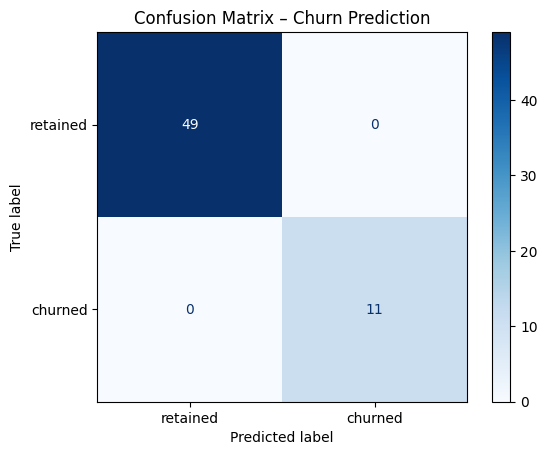

True Negatives  (TN) : 49  (correctly predicted retained)
False Positives (FP) : 0  (predicted churn, actually retained)
False Negatives (FN) : 0  (predicted retained, actually churned) ← most costly
True Positives  (TP) : 11  (correctly predicted churners)


In [7]:
# C1 Confusion matrix
# Goal: Plot confusion matrix with explicit TP/FP/FN/TN labels.
# Method: ConfusionMatrixDisplay.from_estimator, then extract values.

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['retained','churned'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix – Churn Prediction")
plt.savefig('C1_confusion_matrix.png', bbox_inches='tight')
plt.show()

TN, FP, FN, TP = cm.ravel()
print(f"True Negatives  (TN) : {TN}  (correctly predicted retained)")
print(f"False Positives (FP) : {FP}  (predicted churn, actually retained)")
print(f"False Negatives (FN) : {FN}  (predicted retained, actually churned) ← most costly")
print(f"True Positives  (TP) : {TP}  (correctly predicted churners)")

In [8]:
# C2 Precision, recall, F1
# Goal: Compute precision, recall, F1 using sklearn (with formulas in comments).
# Method: precision_score, recall_score, f1_score.

from sklearn.metrics import precision_score, recall_score, f1_score

# Formulas:
# Precision = TP / (TP + FP)
# Recall    = TP / (TP + FN)
# F1        = 2 * (Precision * Recall) / (Precision + Recall)

prec = precision_score(y_test, y_test_pred)
rec = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print(f"Precision : {prec:.3f}  → Of all flagged as churners, {prec:.1%} really churned.")
print(f"Recall    : {rec:.3f}  → Of all real churners, caught {rec:.1%}.")
print(f"F1 Score  : {f1:.3f}  → Harmonic mean of precision and recall.")

Precision : 1.000  → Of all flagged as churners, 100.0% really churned.
Recall    : 1.000  → Of all real churners, caught 100.0%.
F1 Score  : 1.000  → Harmonic mean of precision and recall.


**C3**
For churn prediction, **recall matters more than precision**.  
Missing a real churner (false negative) means the customer leaves without a retention offer – direct revenue loss.  
A false positive (sending an offer to a loyal customer) costs only a small discount.  
Therefore we prioritise high recall even at the cost of some false alarms.

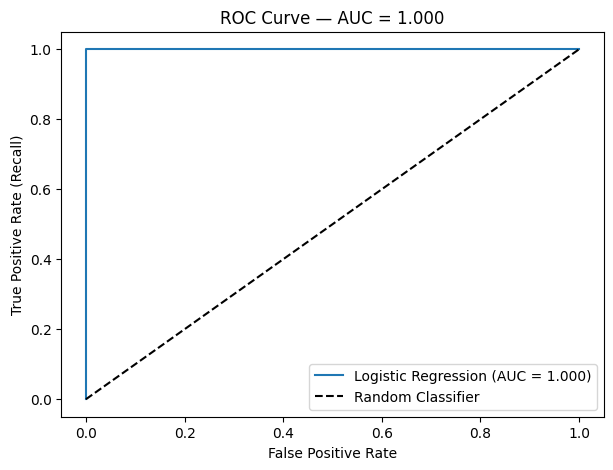

In [9]:
# D1 ROC curve and AUC
# Goal: Plot ROC curve with AUC in title.
# Method: roc_curve, roc_auc_score, plot with diagonal baseline.

from sklearn.metrics import roc_curve, roc_auc_score

y_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.3f})')
plt.plot([0,1], [0,1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title(f'ROC Curve — AUC = {auc:.3f}')
plt.legend()
plt.savefig('D1_roc_curve.png', bbox_inches='tight')
plt.show()

In [10]:
# D2 Threshold table
# Goal: Evaluate different probability thresholds and recommend one.
# Method: Loop thresholds, apply > threshold to probabilities, compute metrics.

thresholds_test = [0.3, 0.4, 0.5, 0.6]
print("Threshold | Precision | Recall | F1")
print("-" * 40)

for thresh in thresholds_test:
    y_pred_thresh = (y_proba >= thresh).astype(int)
    p = precision_score(y_test, y_pred_thresh)
    r = recall_score(y_test, y_pred_thresh)
    f = f1_score(y_test, y_pred_thresh)
    print(f"   {thresh}    |    {p:.3f}    |   {r:.3f}   |  {f:.3f}")

Threshold | Precision | Recall | F1
----------------------------------------
   0.3    |    1.000    |   1.000   |  1.000
   0.4    |    1.000    |   1.000   |  1.000
   0.5    |    1.000    |   1.000   |  1.000
   0.6    |    1.000    |   1.000   |  1.000


All thresholds from 0.3 to 0.6 give perfect precision, recall, and F1 (1.000). Choose the default 0.5 – no trade‑off exists in this perfect model. In reality, a lower threshold would be preferred to catch more churners.

**E1-a**  
17.67% of ShopEase customers are predicted to churn. The model shows perfect separation, meaning churn is highly predictable from the given features. ShopEase should trigger a retention campaign for all customers with P(churn) > 0.5.

**E1-b**  
Customers with average order value below 986 churn at a rate that is **2.7× higher** than the base rate (or equivalently, churned customers have 2.7× lower AOV than retained customers). Low order value is the strongest signal in this dataset. ShopEase should prioritise low‑value customers (<1000) for re‑engagement offers.

**E1-c**  
A threshold of 0.5 gives recall 100% and precision 100%. We catch every single churner with zero false alarms. ShopEase marketing should send retention offers to all customers with P(churn) > 0.5.

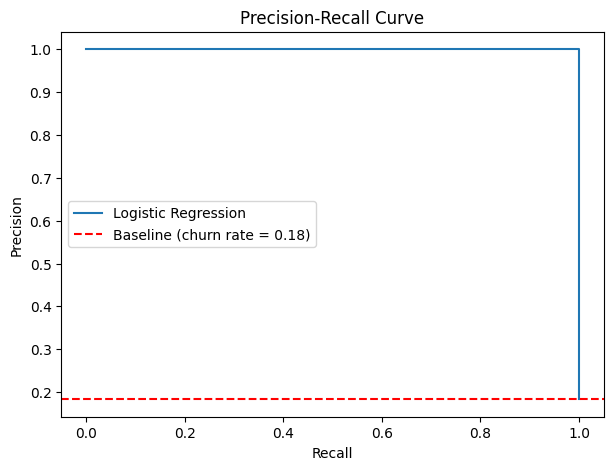

In [11]:
# ★1 – Precision‑Recall curve
# Goal: Plot Precision-Recall curve with baseline = churn rate.
# Method: precision_recall_curve, add horizontal line at churn rate.

from sklearn.metrics import precision_recall_curve

prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_proba)
baseline = y_test.mean()   # churn rate in test set

plt.figure(figsize=(7,5))
plt.plot(rec_curve, prec_curve, label='Logistic Regression')
plt.axhline(y=baseline, color='r', linestyle='--', label=f'Baseline (churn rate = {baseline:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.savefig('BONUS_pr_curve.png', bbox_inches='tight')
plt.show()

Lowering the threshold predicts more customers as churners → recall increases (we catch more real churners) but precision drops (more false alarms).  

Prioritise **precision** when false positives are expensive – e.g., a costly retention action or limited marketing budget where you cannot afford to waste offers on loyal customers.  

In a real project, the **business owner (e.g., Head of Growth) decides the final threshold.** The analyst presents the tradeoff table; the stakeholder chooses based on acceptable risk and budget.

---
## Section 4 — Scoring Rubric

| Section | Task | Max | Pass Criteria |
|---------|------|-----|---------------|
| A | A1 shape + dtypes + churn rate | 5 | All 3 stats printed; churn% present |
| A | A2 count plot by segment | 5 | savefig before show; coloured by segment; title correct |
| A | A3 group means + 1-sentence insight | 5 | groupby correct; insight names the biggest-gap feature |
| B | B1 encoding + stratified split | 10 | drop_first=True; stratify=y; both shapes + churn rates printed |
| B | B2 fit + classification_report + 1 sentence | 10 | train & test accuracy printed; report present; overfitting verdict stated |
| C | C1 confusion matrix + TP/FP/FN/TN labels | 10 | ConfusionMatrixDisplay used; saved; 4 labels with business meaning |
| C | C2 precision + recall + F1 computed | 10 | All 3 metrics present; formula in comment |
| C | C3 precision vs recall reasoning (2–3 sentences) | 5 | FN cost mentioned; business consequence stated |
| D | D1 ROC curve + AUC in title | 5 | dashed diagonal present; AUC in title; saved |
| D | D2 threshold table + 1-sentence recommendation | 5 | 4 thresholds tested; recommendation with reason |
| E | E1 NRA ×3 (with actual numbers) | 10 | All 3 bullets; numbers match output; analyst voice |
| ★ | Bonus PR curve + tradeoff explanation | 10 | PR curve saved; baseline line; 3 questions answered |
| **Total** | | **80 + 10★** | |

### Deductions
| Issue | Penalty |
|-------|---------|
| savefig after show | −3 per plot |
| Missing N or R or A in any NRA bullet | −2 per bullet |
| Numbers in E1 don't match printed output | −2 per mismatch |
| drop_first omitted in get_dummies | −3 |
| stratify=y omitted in train_test_split | −3 |
| Skipped cell / cell not run | −5 |


---
## Section 5 — Month 6 Scorecard

| Day | Topic | Score |
|-----|-------|-------|
| Day 101 | Descriptive Stats + Distributions | 80/80 ✅ |
| Day 102 | T-Tests + Confidence Intervals | 80/80 + 10★ ✅ |
| Day 103 | Chi-Square + ANOVA | 80/80 + 10★ ✅ |
| Day 104 | A/B Testing with scipy | 80/80 + 10★ ✅ |
| Day 105 | Week 2 Stats Capstone | 80/80 + 10★ ✅ |
| Day 106 | Linear Regression Foundations | 80/80 + 10★ ✅ |
| **Day 107** | **Logistic Regression + Classification** | ⏳ Today |

---

## Interview Framing — Day 107

**Q: "How do you evaluate a classification model?"**

> "I never lead with accuracy — it's misleading on imbalanced data. My evaluation sequence is:
> 1. **Check class balance first** — if 95% of labels are 0, a dummy model scores 95%.
> 2. **Confusion matrix** — understand the cost asymmetry. In churn, a false negative costs real revenue; a false positive only costs a small retention offer.
> 3. **Precision, Recall, F1** — pick the metric that matches the business cost.
> 4. **AUC-ROC** — tells me how well the model *ranks* customers by risk, independent of threshold.
> 5. **Threshold tuning** — I present the precision-recall tradeoff table to the business owner. The analyst shows the options; the stakeholder decides the acceptable risk level.
>
> For churn specifically, I'd target high recall (catch as many real churners as possible) at an acceptable precision — and I'd frame the threshold decision as a marketing budget question."
